In [6]:
import pandas as pd

df = pd.read_csv("cine21_reviews.csv")
print(df.shape)
df.head(10)

(98, 4)


,id,date,rating,comment
0,178*****,2026-07-24 00:36:59,8,"곡성이 나홍진의 최고작이 될 수 있었던 이유는, 감독이 영화 안에 그럴싸한 공란을 ..."
1,158*****,2026-07-23 23:01:43,2,모든 사람들이 만족할 수 없는 영화이다. 나에게는 최악의 영화이다.영화가 너무 뾰족...
2,103*****,2026-07-23 21:04:53,1,"이걸 쓰레기라고 말하지 못한다면, 앞으로도 작품을 출품하는게 아니라 똥을 배설하는 ..."
3,112*****,2026-07-23 19:51:06,2,한줄요약해드립니다가오갤+진격거+약깐의 스즈메의 문단속+한국액션느낌=딱이느낌입니다.이...
4,500*****,2026-07-23 15:56:12,10,호프를 시작으로 우리 영화도 더 빠르게 진화할거라는 희망이 든다.조인성과 정호연 다...
5,191*****,2026-07-23 09:15:34,4,"이 영화는 진짜 끝까지 봐야 평가할 수 있는 영화다. 그래서 별도 2개... 2,3..."
6,431*****,2026-07-23 00:10:01,10,연출.연기.음악 모든 게 완벽한 영화.끝날 때까지 긴장하고 봤다.너무 잼있어서 또 ...
7,491*****,2026-07-22 21:18:38,5,"액션신과 미장센은 대단하지만, 그 외 모든 부분이 엉성하다."
8,500*****,2026-07-22 20:14:53,10,2시간30분동안 계속 긴장최고의 영화
9,500*****,2026-07-22 14:52:50,1,영화를 돈으로만보고 관객수만 늘릴려는 의도의 영화들은 이제 망한다고본다


In [ ]:
df.info() #결측치 확인
df['rating'].value_counts() #다 숫자인지 확인

<class 'pandas.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       98 non-null     str  
 1   date     98 non-null     str  
 2   rating   98 non-null     int64
 3   comment  98 non-null     str  
dtypes: int64(1), str(3)
memory usage: 31.0 KB


rating
1     30
10    27
8      8
9      7
5      6
2      5
7      5
4      4
6      4
3      2
Name: count, dtype: int64

In [8]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [9]:
print(df.duplicated().sum()) #중복 리뷰 확인

0


In [ ]:
df['rating'].describe()
df['rating'].value_counts().sort_index() #10점 만점인지 확인

rating
1     30
2      5
3      2
4      4
5      6
6      4
7      5
8      8
9      7
10    27
Name: count, dtype: int64

In [ ]:
df['comment_len'] = df['comment'].str.len() #코멘트 길이 컬럼 생성

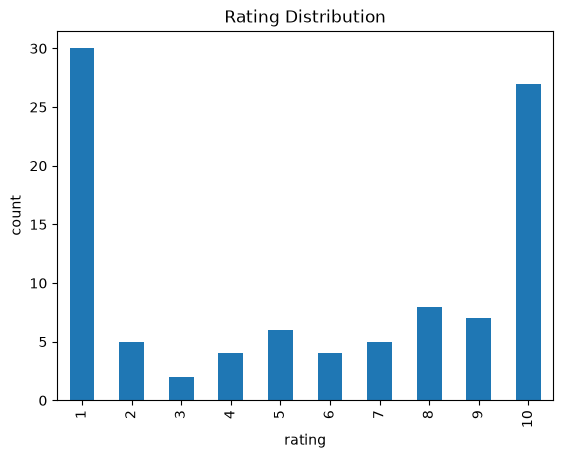

count    98.000000
mean      5.591837
std       3.779589
min       1.000000
25%       1.000000
50%       6.000000
75%      10.000000
max      10.000000
Name: rating, dtype: float64
Standard Deviation: 3.779589064811522


In [ ]:
import matplotlib.pyplot as plt

#평점 분포 시각화
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('rating')
plt.ylabel('count')
plt.title('Rating Distribution')
plt.show()

print(df['rating'].describe())
print("Standard Deviation:", df['rating'].std())

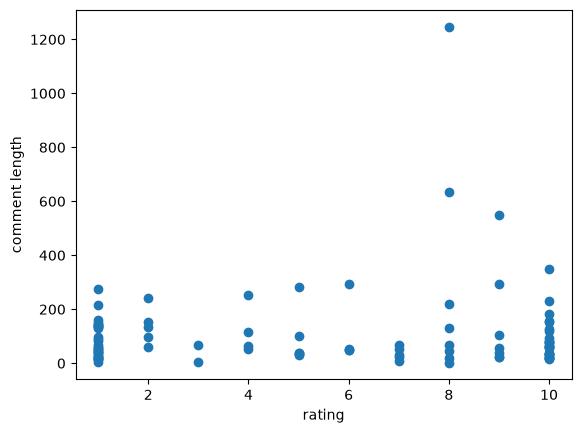

rating
1      83.466667
2     137.200000
3      36.000000
4     121.000000
5      87.666667
6     110.250000
7      37.000000
8     295.875000
9     155.285714
10     85.444444
Name: comment_len, dtype: float64

In [ ]:
# 코멘트 길이 vs 평점

df['comment_len'] = df['comment'].str.len()

plt.scatter(df['rating'], df['comment_len'])
plt.xlabel('rating')
plt.ylabel('comment length')
plt.show()

df.groupby('rating')['comment_len'].mean()

In [ ]:
positive_words = ['최고', '재밌', '감동', '명작', '인생작', '추천']
negative_words = ['최악', '쓰레기', '노잼', '실망', '돈아깝', '별로', '환불', '한숨']

def contains_word(text, words):
    return any(w in text for w in words)

df['has_positive'] = df['comment'].apply(lambda x: contains_word(x, positive_words))
df['has_negative'] = df['comment'].apply(lambda x: contains_word(x, negative_words))

df.groupby('has_positive')['rating'].mean()
df.groupby('has_negative')['rating'].mean()

has_negative
False    5.829545
True     3.500000
Name: rating, dtype: float64

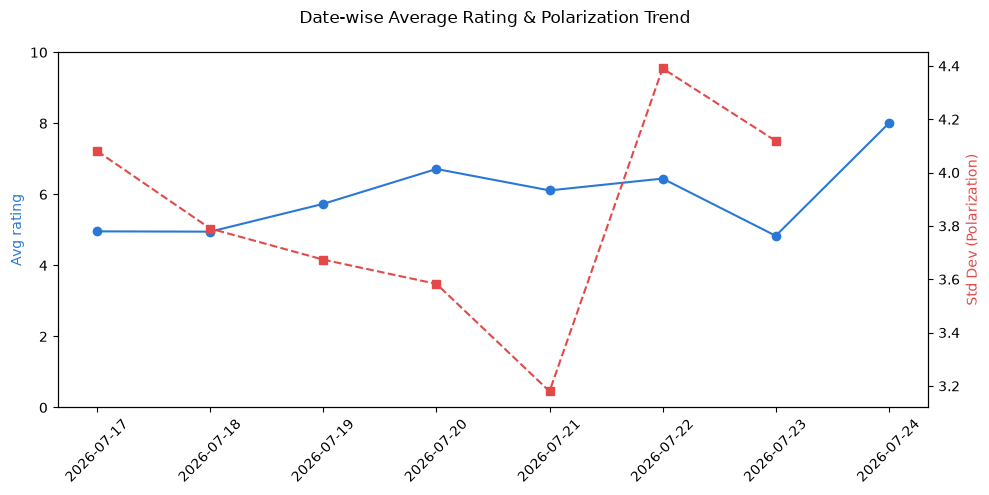

          day      mean       std  count
0  2026-07-17  4.958333  4.080486     24
1  2026-07-18  4.950000  3.790223     20
2  2026-07-19  5.733333  3.673587     15
3  2026-07-20  6.714286  3.582620     14
4  2026-07-21  6.111111  3.179797      9
5  2026-07-22  6.444444  4.390647      9
6  2026-07-23  4.833333  4.119061      6
7  2026-07-24  8.000000       NaN      1


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 날짜에 따른 평점 양극화 추이
df['date'] = pd.to_datetime(df['date'])
df['day'] = df['date'].dt.date

daily = df.groupby('day')['rating'].agg(['mean', 'std', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(daily['day'], daily['mean'], marker='o', color='#2a78d6', label='Avg rating')
ax1.set_ylabel('Avg rating', color='#2a78d6')
ax1.set_ylim(0, 10)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(daily['day'], daily['std'], marker='s', color='#e34948', linestyle='--', label='Std Dev (Polarization)')
ax2.set_ylabel('Std Dev (Polarization)', color='#e34948')

fig.suptitle('Date-wise Average Rating & Polarization Trend')
fig.tight_layout()
plt.show()

print(daily)